# Project 3: FPGA ECG filtering and Python peak analysis
Run each code cell in order with **Shift + Enter**. Existing `ecg_filter.bit` and
`ecg_filter.hwh` must be in the same folder as this notebook and its three support files.
No board Internet access or WFDB installation is needed.
This demonstrates **recorded ECG replay**: filtering executes in the FPGA; peak
detection and heart-rate estimation execute in Python on the ARM processor.
The nominal filter was designed for 360 Hz sampling. These tests check 5 Hz
preservation and 50 Hz rejection, not the complete claimed passband.


In [1]:
from pathlib import Path
import json, time
import numpy as np
import matplotlib.pyplot as plt
from pynq import Overlay, allocate

FS, N = 360, 2048
for name in ['ecg_filter.bit', 'ecg_filter.hwh', 'fir_reference.json',
             'ecg_record100_360hz.csv', 'DATA_SOURCE.md']:
    assert Path(name).is_file(), 'Missing file: ' + name

model = json.loads(Path('fir_reference.json').read_text())
hq = np.array(model['coefficients_q412'], dtype=np.int64)
assert len(hq) == 128
overlay = Overlay('ecg_filter.bit')
assert overlay.is_loaded()
dma = overlay.axi_dma_0
in_buf = allocate(shape=(N,), dtype=np.int16)
out_buf = allocate(shape=(N,), dtype=np.int16)
print('OVERLAY LOADED:', overlay.is_loaded())
print('DMA:', 'axi_dma_0')
print('FPGA FIR / 16-bit Q4.12 / 2048 samples per transaction')


OVERLAY LOADED: True
DMA: axi_dma_0
FPGA FIR / 16-bit Q4.12 / 2048 samples per transaction


## Transfer helper and fixed-point reference
The reference models the actual decimal coefficient conversion, truncation
of each product to Q4.20, accumulator wrap, and final Q4.12 conversion.
Zero flushing makes each independent test start with a known FIR history.
If a transfer fails, stop and send the error; do not continue to the plots.


In [4]:
def encode_q412(values):
    q = np.rint(np.asarray(values) * 4096)
    assert np.all(np.isfinite(q)), 'Input contains NaN/Inf'
    assert q.min() >= -32768 and q.max() <= 32767, 'Q4.12 input overflow'
    return q.astype(np.int16)

def fpga_filter(q):
    q = np.asarray(q)
    assert q.shape == (N,) and q.dtype == np.int16
    in_buf[:] = q
    out_buf[:] = 0
    in_buf.flush()
    out_buf.flush()
    dma.recvchannel.transfer(out_buf)
    dma.sendchannel.transfer(in_buf)
    deadline = time.monotonic() + 10
    while True:
        tx = dma.mmio.read(0x04)
        rx = dma.mmio.read(0x34)
        if (tx | rx) & 0x70:
            raise RuntimeError(f'DMA error: TX={tx:#010x}, RX={rx:#010x}')
        if dma.sendchannel.idle and dma.recvchannel.idle:
            break
        if time.monotonic() > deadline:
            raise TimeoutError(f'DMA timeout: TX={tx:#010x}, RX={rx:#010x}')
        time.sleep(0.001)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    out_buf.invalidate()
    return np.array(out_buf, dtype=np.int16)

def fixed_reference(q):
    q = np.asarray(q, dtype=np.int64)
    acc = np.zeros(len(q), dtype=np.int64)
    for j, c in enumerate(hq):
        acc[j:] += (q[:len(q)-j] * c) >> 4
    acc = (acc + (1 << 23)) % (1 << 24) - (1 << 23)
    y = acc >> 8
    return ((y + 32768) % 65536 - 32768).astype(np.int16)

def check_reference(q, actual, label):
    expected = fixed_reference(q)
    error = np.abs(actual.astype(np.int32) - expected.astype(np.int32))
    max_error = int(error.max())
    print(f'{label}: maximum error = {max_error} Q4.12 LSB')
    print(f'{label}: samples within 1 LSB = {int(np.count_nonzero(error <= 1))}/{len(q)}')
    assert max_error <= 1, label + ': reference mismatch; stop and inspect the build/model'
    print(label + ': NUMERICAL CHECK PASS')
    return expected, max_error

def tone_amplitudes(y, t):
    t, y = t[256:], np.asarray(y)[256:]
    A = np.column_stack([np.sin(2*np.pi*5*t), np.cos(2*np.pi*5*t),
                         np.sin(2*np.pi*50*t), np.cos(2*np.pi*50*t),
                         np.ones(len(t))])
    p = np.linalg.lstsq(A, y, rcond=-1.0)[0]
    return float(np.hypot(p[0], p[1])), float(np.hypot(p[2], p[3]))

print('Helpers ready. Reference uses the supplied final HLS code.')


Helpers ready. Reference uses the supplied final HLS code.


## 1. Numerical verification and interference rejection
The test input is a 1.0-amplitude 5 Hz sine plus a 0.5-amplitude 50 Hz sine.
Pass criteria: reference error <= 1 Q4.12 LSB, 5 Hz gain 0.8 to 1.2,
and at least 26 dB reduction of the 50 Hz tone. Those are demonstration
acceptance thresholds, not clinical criteria or a complete frequency-response test.


SINE TEST: maximum error = 0 Q4.12 LSB
SINE TEST: samples within 1 LSB = 2048/2048
SINE TEST: NUMERICAL CHECK PASS
5 Hz gain: 0.9940
50 Hz interference reduction: 53.74 dB
FREQUENCY CHECK PASS


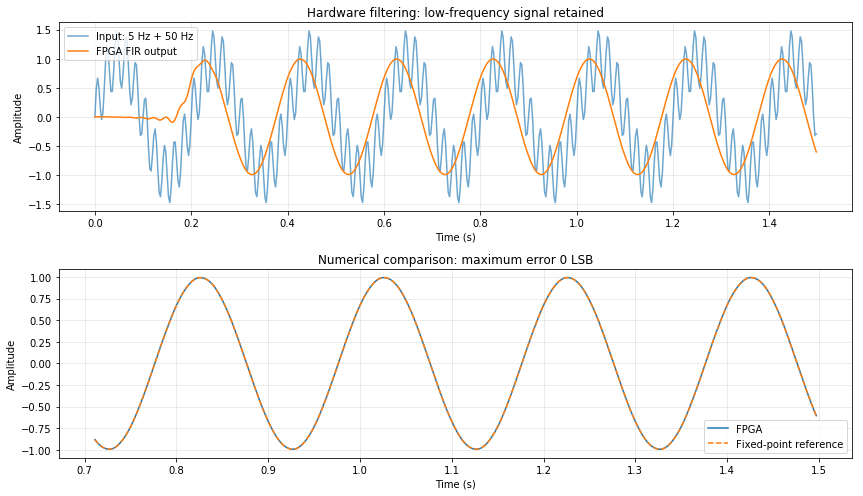

In [5]:
fpga_filter(np.zeros(N, dtype=np.int16))
t_sine = np.arange(N) / FS
input_sine = np.sin(2*np.pi*5*t_sine) + 0.5*np.sin(2*np.pi*50*t_sine)
q_sine = encode_q412(input_sine)
hw_sine = fpga_filter(q_sine)
ref_sine, sine_max_error = check_reference(q_sine, hw_sine, 'SINE TEST')
y_sine = hw_sine.astype(float) / 4096
input_5, input_50 = tone_amplitudes(q_sine.astype(float)/4096, t_sine)
output_5, output_50 = tone_amplitudes(y_sine, t_sine)
gain_5 = output_5 / input_5
attenuation_50 = 20*np.log10(input_50/max(output_50, 1e-12))
print(f'5 Hz gain: {gain_5:.4f}')
print(f'50 Hz interference reduction: {attenuation_50:.2f} dB')
assert 0.8 <= gain_5 <= 1.2 and attenuation_50 >= 26, 'Frequency check failed'
print('FREQUENCY CHECK PASS')

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(t_sine[:540], input_sine[:540], alpha=0.65, label='Input: 5 Hz + 50 Hz')
ax[0].plot(t_sine[:540], y_sine[:540], label='FPGA FIR output')
ax[0].set(title='Hardware filtering: low-frequency signal retained', xlabel='Time (s)', ylabel='Amplitude')
ax[1].plot(t_sine[256:540], y_sine[256:540], label='FPGA')
ax[1].plot(t_sine[256:540], ref_sine[256:540]/4096, '--', label='Fixed-point reference')
ax[1].set(title=f'Numerical comparison: maximum error {sine_max_error} LSB', xlabel='Time (s)', ylabel='Amplitude')
for a in ax:
    a.legend(); a.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('01_sine_verification.png', dpi=150)
plt.show()


## 2. Recorded ECG through the FPGA
The CSV is a real 34.13-second excerpt of MIT-BIH record 100, MLII lead.
We subtract the median and deliberately add 0.15 mV of 50 Hz interference.
Six consecutive 2048-sample transactions check that FIR history survives
DMA boundaries. The measured wall time includes Python and DMA overhead;
it is not standalone FPGA pipeline latency.


In [6]:
recorded_ecg = np.loadtxt('ecg_record100_360hz.csv', skiprows=1)
assert len(recorded_ecg) == 6*N
t_ecg = np.arange(len(recorded_ecg)) / FS
centered_ecg = recorded_ecg - np.median(recorded_ecg)
input_ecg = centered_ecg + 0.15*np.sin(2*np.pi*50*t_ecg)
q_ecg = encode_q412(input_ecg)

fpga_filter(np.zeros(N, dtype=np.int16))
started = time.perf_counter()
hw_ecg = np.concatenate([fpga_filter(q_ecg[k:k+N]) for k in range(0, len(q_ecg), N)])
transfer_seconds = time.perf_counter() - started
ref_ecg, ecg_max_error = check_reference(q_ecg, hw_ecg, 'RECORDED ECG')
filtered_ecg = hw_ecg.astype(float)/4096
print(f'ECG samples processed: {len(q_ecg)} in {len(q_ecg)//N} DMA batches')
print(f'Recorded duration: {len(q_ecg)/FS:.2f} seconds')
print(f'Python + DMA wall time: {transfer_seconds*1000:.2f} ms (not FPGA-only latency)')
print('CONTINUOUS MULTI-BATCH CHECK PASS')


RECORDED ECG: maximum error = 0 Q4.12 LSB
RECORDED ECG: samples within 1 LSB = 12288/12288
RECORDED ECG: NUMERICAL CHECK PASS
ECG samples processed: 12288 in 6 DMA batches
Recorded duration: 34.13 seconds
Python + DMA wall time: 7.55 ms (not FPGA-only latency)
CONTINUOUS MULTI-BATCH CHECK PASS


## 3. Simple Python peak and heart-rate demonstration
This height threshold and 300 ms separation detector is tuned to this excerpt.
It is not full Pan-Tompkins, arrhythmia classification, or database-wide accuracy
validation. Heart rate is 60 divided by the mean detected RR interval.
The symmetric 128-tap FIR introduces 63.5 samples of group delay. The ECG
plot compensates that delay for visual alignment; RR intervals do not need
delay compensation because the same delay applies to each detected peak.


Detected peaks: 42
Mean RR interval: 0.812 s
Estimated heart rate: 73.9 beats/min
Peak analysis: Python on ARM; FIR filtering: FPGA


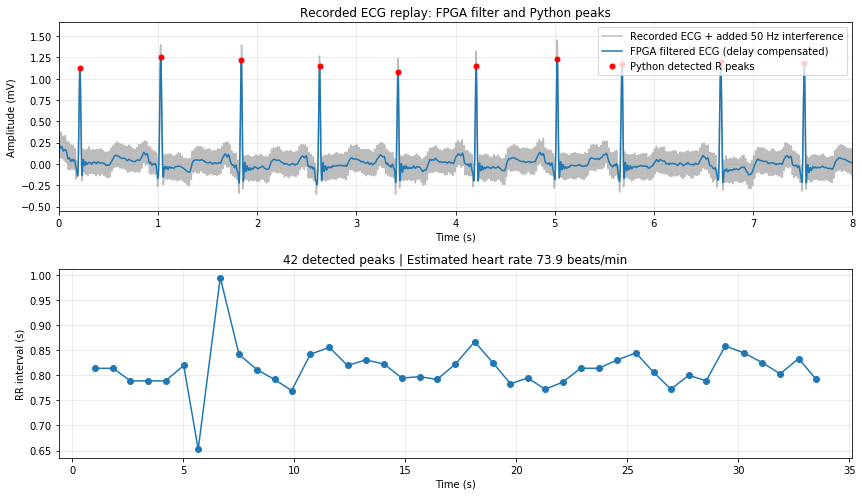

In [7]:
baseline = float(np.median(filtered_ecg))
peak_threshold = baseline + 0.45*(np.percentile(filtered_ecg, 99)-baseline)
candidates = np.where((filtered_ecg[1:-1] > filtered_ecg[:-2]) &
                      (filtered_ecg[1:-1] >= filtered_ecg[2:]))[0] + 1
candidates = candidates[(filtered_ecg[candidates] > peak_threshold) &
                        (candidates >= 128) & (candidates < len(filtered_ecg)-128)]
chosen = []
for p in candidates[np.argsort(filtered_ecg[candidates])[::-1]]:
    if all(abs(int(p)-k) >= int(round(0.30*FS)) for k in chosen):
        chosen.append(int(p))
peaks = np.array(sorted(chosen), dtype=int)
assert len(peaks) >= 3, 'Insufficient detected peaks; send the ECG plot'
rr_seconds = np.diff(peaks)/FS
heart_rate = float(60/np.mean(rr_seconds))
print('Detected peaks:', len(peaks))
print(f'Mean RR interval: {np.mean(rr_seconds):.3f} s')
print(f'Estimated heart rate: {heart_rate:.1f} beats/min')
print('Peak analysis: Python on ARM; FIR filtering: FPGA')

delay_seconds = 63.5/FS
display_time = t_ecg - delay_seconds
peak_times = display_time[peaks]
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(t_ecg, input_ecg, color='0.6', alpha=0.65, label='Recorded ECG + added 50 Hz interference')
ax[0].plot(display_time, filtered_ecg, label='FPGA filtered ECG (delay compensated)')
ax[0].plot(peak_times, filtered_ecg[peaks], 'ro', ms=5, label='Python detected R peaks')
ax[0].set(xlim=(0,8), xlabel='Time (s)', ylabel='Amplitude (mV)', title='Recorded ECG replay: FPGA filter and Python peaks')
ax[1].plot(peak_times[1:], rr_seconds, 'o-')
ax[1].set(xlabel='Time (s)', ylabel='RR interval (s)', title=f'{len(peaks)} detected peaks | Estimated heart rate {heart_rate:.1f} beats/min')
for a in ax:
    a.legend() if a is ax[0] else None
    a.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('02_ecg_peaks.png', dpi=150)
plt.show()


## 4. Save your board results
The result files below are evidence from this board run. Save the notebook
with Ctrl+S and download the notebook and generated files through Jupyter.


In [8]:
results = {
    'record': 'MIT-BIH 100 / MLII / samples 0..12287',
    'sampling_rate_hz': FS, 'batch_samples': N, 'ecg_samples': int(len(q_ecg)),
    'sine_max_error_lsb': sine_max_error, 'ecg_max_error_lsb': ecg_max_error,
    'gain_5hz': gain_5, 'attenuation_50hz_db': float(attenuation_50),
    'detected_peaks': int(len(peaks)), 'estimated_heart_rate_bpm': heart_rate,
    'python_dma_wall_time_seconds': transfer_seconds,
    'reference_test_pass': bool(sine_max_error <= 1 and ecg_max_error <= 1),
    'frequency_test_pass': bool(0.8 <= gain_5 <= 1.2 and attenuation_50 >= 26),
    'peak_method': 'Python height threshold + 300 ms minimum separation',
    'input_mode': 'Recorded ECG replay; no live sensor acquisition demonstrated'
}
Path('hardware_results.json').write_text(json.dumps(results, indent=2))
peak_flags = np.zeros(len(q_ecg), dtype=int)
peak_flags[peaks] = 1
np.savetxt('hardware_ecg_results.csv',
           np.column_stack([t_ecg, recorded_ecg, input_ecg, filtered_ecg,
                            ref_ecg.astype(float)/4096, peak_flags]),
           delimiter=',', header='time_s,recorded_ecg_mV,input_with_noise_mV,fpga_output_mV,reference_mV,detected_peak',
           comments='', fmt=['%.6f','%.6f','%.6f','%.6f','%.6f','%d'])
np.savetxt('detected_peaks.csv', np.column_stack([peaks, peak_times]), delimiter=',',
           header='output_sample_index,delay_compensated_time_s', comments='', fmt=['%d','%.6f'])
print('BOARD DEMO CHECKS PASSED')
print('Saved hardware_results.json, hardware_ecg_results.csv, detected_peaks.csv')
print('Saved 01_sine_verification.png and 02_ecg_peaks.png')
print('Now press Ctrl+S and download the notebook/results for submission.')
in_buf.freebuffer()
out_buf.freebuffer()


BOARD DEMO CHECKS PASSED
Saved hardware_results.json, hardware_ecg_results.csv, detected_peaks.csv
Saved 01_sine_verification.png and 02_ecg_peaks.png
Now press Ctrl+S and download the notebook/results for submission.
